In [7]:
import numpy as np
from pathlib import Path
import tifffile as tiff

import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb

from pycromanager import Core

In [8]:
_MM_STATE = {
    "core": None,
}

def connect_core(reset=False):
    """
    Create one persistent Core connection to a running Micro-Manager.
    """
    global _MM_STATE

    if reset:
        _MM_STATE["core"] = None

    if _MM_STATE["core"] is not None:
        return _MM_STATE["core"]

    try:
        core = Core()
        _MM_STATE["core"] = core
        print("Connected to Micro-Manager through pycromanager.Core().")
        return core
    except Exception as e:
        raise RuntimeError(
            "Could not create a pycromanager Core connection to Micro-Manager.\n"
            "Please check:\n"
            "1. Micro-Manager is already open.\n"
            "2. Micro-Manager finished launching completely.\n"
            "3. pycromanager is installed in the same Python environment.\n"
            "4. If connection is stale, try connect_core(reset=True).\n"
            f"\nOriginal error:\n{e}"
        ) from e

In [9]:
def snap_and_get_frame(core=None):
    """
    Acquire one single frame by:
    1. snap_image()
    2. get_tagged_image()
    3. reshape pixel buffer to 2D image
    """
    if core is None:
        core = connect_core()

    core.snap_image()
    tagged = core.get_tagged_image()

    h = tagged.tags["Height"]
    w = tagged.tags["Width"]
    raw = np.reshape(tagged.pix, (h, w))

    return raw


def get_frame_shape(core=None):
    """
    Get frame shape using one snapped image.
    """
    raw = snap_and_get_frame(core)
    return raw.shape

In [10]:
core = connect_core(reset=True)
raw_test = snap_and_get_frame(core)

print("Test frame shape:", raw_test.shape)
print("Test frame dtype:", raw_test.dtype)
print("Min / Max:", raw_test.min(), raw_test.max())
print("Nonzero pixel count:", np.count_nonzero(raw_test))

Connected to Micro-Manager through pycromanager.Core().
Test frame shape: (512, 512)
Test frame dtype: uint16
Min / Max: 706 5846
Nonzero pixel count: 262144


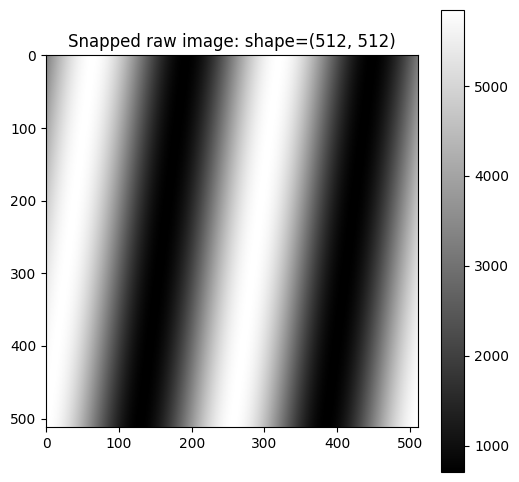

In [11]:
plt.figure(figsize=(6, 6))
plt.imshow(raw_test, cmap="gray")
plt.colorbar()
plt.title(f"Snapped raw image: shape={raw_test.shape}")
plt.show()

In [12]:
def save_dark_tiff(dark, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tiff.imwrite(str(path), np.asarray(dark, dtype=np.float32))
    print(f"Saved dark frame to: {path}")


def load_dark_tiff(path):
    path = Path(path)
    dark = tiff.imread(str(path)).astype(np.float64)
    print(f"Loaded dark frame from: {path}")
    return dark

In [13]:
def acquire_dark_frame(n_frames=16, save_path=None, core=None):
    """
    Acquire an averaged dark/background frame using repeated single snaps.
    """
    if core is None:
        core = connect_core()

    print("=" * 60)
    print("Dark-frame acquisition")
    print("Please block illumination / close shutter / move to background now.")
    input("Press Enter to acquire dark/background frames...")

    frames = []
    for i in range(n_frames):
        raw = snap_and_get_frame(core).astype(np.float64)
        frames.append(raw)
        print(f"Captured dark frame {i + 1}/{n_frames}")

    dark = np.mean(frames, axis=0)
    print("Dark/background acquisition complete.")

    if save_path is not None:
        save_dark_tiff(dark, save_path)

    print("=" * 60)
    return dark

In [14]:
def split_pol_channels(raw):
    """
    mosaic:
        [ I0,   I135 ]
        [ I45,  I90  ]
    """
    raw = np.asarray(raw)

    if raw.ndim not in (2, 3):
        raise ValueError(f"Expected 2D or 3D image, got shape {raw.shape}")

    H = raw.shape[-2]
    W = raw.shape[-1]
    if (H % 2 != 0) or (W % 2 != 0):
        raise ValueError(f"Image height and width must be even, got shape {raw.shape}")

    if raw.ndim == 2:
        I0 = raw[0::2, 0::2]
        I135 = raw[0::2, 1::2]
        I45 = raw[1::2, 0::2]
        I90 = raw[1::2, 1::2]
    else:
        I0 = raw[:, 0::2, 0::2]
        I135 = raw[:, 0::2, 1::2]
        I45 = raw[:, 1::2, 0::2]
        I90 = raw[:, 1::2, 1::2]

    return I0, I45, I90, I135

In [15]:
def match_dark_shape(raw, dark):
    raw = np.asarray(raw)
    dark = np.asarray(dark, dtype=np.float64)

    if raw.ndim == 2 and dark.ndim == 2:
        return dark

    if raw.ndim == 3 and dark.ndim == 2:
        return dark[None, :, :]

    if raw.ndim == 3 and dark.ndim == 3:
        return dark

    raise ValueError(f"Unsupported raw/dark shapes: raw={raw.shape}, dark={dark.shape}")

In [16]:
def stokes_from_raw(raw, dark, eps=1e-12):
    raw = np.asarray(raw, dtype=np.float64)
    dark = match_dark_shape(raw, dark)

    raw = raw - dark
    raw = np.clip(raw, 0, None)

    I0, I45, I90, I135 = split_pol_channels(raw)

    S0 = 0.5 * (I0 + I45 + I90 + I135)
    s1 = (I0 - I90) / (I0 + I90 + eps)
    s2 = (I45 - I135) / (I45 + I135 + eps)

    return S0, s1, s2

In [17]:
import numpy as np

def theta_delta_from_s1s2(s1, s2, eps=1e-12):
    """
    根据 s1, s2 计算 theta 和 delta

    公式：
        theta = 0.5 * atan2(-s1, s2)   mod [0, 180)
        |delta| = arcsin(sqrt(s1^2 + s2^2))  in [0, 90]

    然后利用
        s1 = -sin(2*theta) * sin(delta)
    判断 sin(delta) 的符号：
        - 若 sin(delta) >= 0，则 delta 保持为 |delta|
        - 若 sin(delta) < 0，则将 delta 映射到 180 - |delta|

    最终 delta unwrap 到 [0, 180)
    """
    s1 = np.asarray(s1, dtype=np.float64)
    s2 = np.asarray(s2, dtype=np.float64)

    # 1) 先算 theta
    theta_deg = (0.5 * np.degrees(np.arctan2(-s1, s2))) % 180.0

    # 2) 沿用原方法计算 |delta|
    r = np.sqrt(s1**2 + s2**2)
    r = np.clip(r, 0.0, 1.0)
    delta_abs_deg = np.degrees(np.arcsin(r))   # in [0, 90]

    # 3) 用 s1 = -sin(2theta) sin(delta) 判断 delta 的符号
    sin2theta = np.sin(np.radians(2.0 * theta_deg))

    # 避免 sin(2theta) 太小时数值不稳定
    # s1 / (-sin2theta) 的符号就是 sin(delta) 的符号
    sin_delta_sign = np.zeros_like(s1)

    mask = np.abs(sin2theta) > eps
    sin_delta_sign[mask] = np.sign(-s1[mask] / sin2theta[mask])

    # 对于 sin(2theta)≈0 的点，s1 本身理论上也应接近 0，此时符号不可可靠判定
    # 默认取正号；如果你希望也可改成依据 s2 或保持 NaN
    sin_delta_sign[~mask] = 1.0

    # 4) 若 sin(delta)<0，则映射到 180-|delta|
    delta_deg = np.where(sin_delta_sign >= 0,
                         delta_abs_deg,
                         180.0 - delta_abs_deg)

    # 5) unwrap 到 [0, 180)
    delta_deg = delta_deg % 180.0

    return theta_deg, delta_deg

In [18]:
def hsv_composite_from_theta_delta(theta_deg, delta_deg):
    """
    Hue = theta, Saturation = 1, Value = delta
    """
    hue = (theta_deg % 180.0) / 180.0
    sat = np.ones_like(hue, dtype=np.float64)
    val = np.clip(delta_deg / 90.0, 0.0, 1.0)

    hsv = np.stack([hue, sat, val], axis=-1)
    rgb = hsv_to_rgb(hsv)
    return rgb

In [19]:
def polarization_params_single_frame(raw, dark, eps=1e-12, s0_threshold=50):
    S0, s1, s2 = stokes_from_raw(raw, dark, eps=eps)

    s1 = np.clip(s1, -1.0, 1.0)
    s2 = np.clip(s2, -1.0, 1.0)

    theta_deg, delta_deg = theta_delta_from_s1s2(s1, s2)

    mask = S0 > s0_threshold
    s1 = np.where(mask, s1, np.nan)
    s2 = np.where(mask, s2, np.nan)
    theta_deg = np.where(mask, theta_deg, np.nan)
    delta_deg = np.where(mask, delta_deg, np.nan)

    rgb = hsv_composite_from_theta_delta(
        np.nan_to_num(theta_deg, nan=0.0),
        np.nan_to_num(delta_deg, nan=0.0),
    )
    rgb[~mask] = 0

    return {
        "S0": S0,
        "s1": s1,
        "s2": s2,
        "theta_deg": theta_deg,
        "delta_deg": delta_deg,
        "rgb": rgb,
    }

In [20]:
dark = load_dark_tiff(r"/Users/sunxiaoyuamanda/Desktop/summer project/demo/demo_dark.tif")

raw = snap_and_get_frame()
result = polarization_params_single_frame(raw, dark, s0_threshold=50)

print("S0 shape:", result["S0"].shape)
print("s1 shape:", result["s1"].shape)
print("s2 shape:", result["s2"].shape)
print("theta shape:", result["theta_deg"].shape)
print("delta shape:", result["delta_deg"].shape)
print("rgb shape:", result["rgb"].shape)
print("s1 min/max:", np.nanmin(result["s1"]), np.nanmax(result["s1"]))
print("s2 min/max:", np.nanmin(result["s2"]), np.nanmax(result["s2"]))
print("theta min/max:", np.nanmin(result["theta_deg"]), np.nanmax(result["theta_deg"]))
print("delta min/max:", np.nanmin(result["delta_deg"]), np.nanmax(result["delta_deg"]))

Loaded dark frame from: /Users/sunxiaoyuamanda/Desktop/summer project/demo/demo_dark.tif
S0 shape: (256, 256)
s1 shape: (256, 256)
s2 shape: (256, 256)
theta shape: (256, 256)
delta shape: (256, 256)
rgb shape: (256, 256, 3)
s1 min/max: -0.22055682494312143 0.2204367975422962
s2 min/max: -0.15838661922770633 0.19532410621247454
theta min/max: 0.0 179.85925227869362
delta min/max: 0.0010916851177110107 15.40225969852507


In [ ]:
%matplotlib qt

2026-08-12 16:30:15.833 Python[86798:9413454] WARNING: Secure coding is automatically enabled for restorable state! However, not on all supported macOS versions of this application. Opt-in to secure coding explicitly by implementing NSApplicationDelegate.applicationSupportsSecureRestorableState:.


In [22]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

plt.ion()

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

im0 = axes[0, 0].imshow(result["S0"], cmap="gray")
axes[0, 0].set_title("S0")
axes[0, 0].axis("off")
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

im1 = axes[0, 1].imshow(result["s1"], cmap="gray", vmin=0.8, vmax=1)
axes[0, 1].set_title("s1")
axes[0, 1].axis("off")
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

im2 = axes[0, 2].imshow(result["s2"], cmap="gray", vmin=-0.4, vmax=0.4)
axes[0, 2].set_title("s2")
axes[0, 2].axis("off")
fig.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

im3 = axes[1, 0].imshow(result["theta_deg"], cmap="inferno", vmin=120, vmax=150)
axes[1, 0].set_title("theta (deg)")
axes[1, 0].axis("off")
fig.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

im4 = axes[1, 1].imshow(result["delta_deg"], cmap="gray", vmin=60, vmax=180)
axes[1, 1].set_title("delta (deg)")
axes[1, 1].axis("off")
fig.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

im5 = axes[1, 2].imshow(result["rgb"])
axes[1, 2].set_title("HSV composite")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, RadioButtons


class LivePolarizationViewerFinal:
    def __init__(
        self,
        core,
        dark,
        s0_threshold=20,
        s0_range=(0, 2000),
        s1_range=(-1.0, 1.0),
        s2_range=(-1.0, 1.0),
        theta_range=(0, 180),
        delta_range=(0, 90),
        default_view="S0",
        hsv_title="HSV composite",
        s0_title="S0",
    ):
        self.core = core
        self.dark = np.asarray(dark, dtype=np.float64)
        self.s0_threshold = s0_threshold
        self.hsv_title = hsv_title
        self.s0_title = s0_title

        raw0 = snap_and_get_frame(self.core)
        self.result = polarization_params_single_frame(
            raw0, self.dark, s0_threshold=self.s0_threshold
        )

        self.scalar_configs = {
            "S0": {
                "cmap": "gray",
                "init_range": s0_range,
                "slider_range": (0.0, max(1.0, float(np.nanmax(self.result["S0"])) * 1.2)),
                "title": "S0",
            },
            "s1": {
                "cmap": "gray",
                "init_range": s1_range,
                "slider_range": (-1.0, 1.0),
                "title": "s1",
            },
            "s2": {
                "cmap": "gray",
                "init_range": s2_range,
                "slider_range": (-1.0, 1.0),
                "title": "s2",
            },
            "theta_deg": {
                "cmap": "hsv",
                "init_range": theta_range,
                "slider_range": (0.0, 180.0),
                "title": "theta (deg)",
            },
            "delta_deg": {
                "cmap": "gray",
                "init_range": delta_range,
                "slider_range": (0.0, 90.0),
                "title": "delta (deg)",
            },
        }

        if default_view not in self.scalar_configs:
            raise ValueError(f"default_view must be one of {list(self.scalar_configs.keys())}")

        self.current_key = default_view
        self.current_vranges = {
            key: list(cfg["init_range"]) for key, cfg in self.scalar_configs.items()
        }

        self._slider_internal_update = False

        self._create_main_window()
        self._create_hsv_window()
        self._create_s0_window()
        self._apply_view(self.current_key, reset_sliders=True)

        plt.show(block=False)

    def _make_theta_delta_composite(self):
        theta = np.asarray(self.result["theta_deg"], dtype=np.float64)
        delta = np.asarray(self.result["delta_deg"], dtype=np.float64)
        s0 = np.asarray(self.result["S0"], dtype=np.float64)

        theta_norm = np.clip(theta / 180.0, 0.0, 1.0)

        valid_mask = np.isfinite(delta) & (s0 >= self.s0_threshold)
        if np.any(valid_mask):
            delta_ref = float(np.nanmax(delta[valid_mask]) + 10.0)
        else:
            delta_ref = 10.0
        delta_ref = max(delta_ref, 1e-12)

        delta_norm = np.clip(delta / delta_ref, 0.0, 1.0)

        cmap = plt.get_cmap("hsv")
        rgb = cmap(theta_norm)[..., :3]
        rgb = rgb * delta_norm[..., None]

        rgb[~np.isfinite(theta)] = 0.0
        rgb[~np.isfinite(delta)] = 0.0
        rgb[s0 < self.s0_threshold] = 0.0
        return rgb

    def _create_main_window(self):
        self.fig = plt.figure(figsize=(8.5, 7.5))
        self.ax_img = self.fig.add_axes([0.08, 0.28, 0.62, 0.64])
        self.ax_radio = self.fig.add_axes([0.76, 0.53, 0.18, 0.30])
        self.ax_vmin = self.fig.add_axes([0.08, 0.16, 0.62, 0.04])
        self.ax_vmax = self.fig.add_axes([0.08, 0.08, 0.62, 0.04])

        self.radio = RadioButtons(
            self.ax_radio,
            labels=list(self.scalar_configs.keys()),
            active=list(self.scalar_configs.keys()).index(self.current_key),
        )
        self.radio.on_clicked(self._on_radio_clicked)

        init_cfg = self.scalar_configs[self.current_key]
        init_vmin, init_vmax = self.current_vranges[self.current_key]
        slider_min, slider_max = init_cfg["slider_range"]

        self.im = self.ax_img.imshow(
            self.result[self.current_key],
            cmap=init_cfg["cmap"],
            vmin=init_vmin,
            vmax=init_vmax,
        )
        self.ax_img.set_title(init_cfg["title"])
        self.ax_img.axis("off")
        self.cbar = self.fig.colorbar(self.im, ax=self.ax_img, fraction=0.046, pad=0.04)

        self.s_vmin = Slider(
            ax=self.ax_vmin,
            label="vmin",
            valmin=slider_min,
            valmax=slider_max,
            valinit=init_vmin,
        )
        self.s_vmax = Slider(
            ax=self.ax_vmax,
            label="vmax",
            valmin=slider_min,
            valmax=slider_max,
            valinit=init_vmax,
        )
        self.s_vmin.on_changed(self._on_slider_changed)
        self.s_vmax.on_changed(self._on_slider_changed)

    def _create_hsv_window(self):
        self.fig_hsv = plt.figure(figsize=(6.5, 6.5))
        try:
            self.fig_hsv.canvas.manager.set_window_title(self.hsv_title)
        except Exception:
            pass
        self.ax_hsv = self.fig_hsv.add_axes([0.08, 0.08, 0.84, 0.84])
        self.im_hsv = self.ax_hsv.imshow(self._make_theta_delta_composite())
        self.ax_hsv.set_title(self.hsv_title)
        self.ax_hsv.axis("off")

    def _create_s0_window(self):
        cfg = self.scalar_configs["S0"]
        vmin, vmax = self.current_vranges["S0"]
        self.fig_s0 = plt.figure(figsize=(6.5, 6.5))
        try:
            self.fig_s0.canvas.manager.set_window_title(self.s0_title)
        except Exception:
            pass
        self.ax_s0 = self.fig_s0.add_axes([0.08, 0.08, 0.78, 0.84])
        self.im_s0 = self.ax_s0.imshow(
            self.result["S0"],
            cmap=cfg["cmap"],
            vmin=vmin,
            vmax=vmax,
        )
        self.ax_s0.set_title(self.s0_title)
        self.ax_s0.axis("off")
        self.cbar_s0 = self.fig_s0.colorbar(self.im_s0, ax=self.ax_s0, fraction=0.046, pad=0.04)

    def _set_slider_bounds(self, slider, vmin, vmax):
        slider.valmin = vmin
        slider.valmax = vmax
        slider.ax.set_xlim(vmin, vmax)

    def _apply_view(self, key, reset_sliders=False):
        self.current_key = key
        cfg = self.scalar_configs[key]
        data = self.result[key]

        self.im.set_data(data)
        self.im.set_cmap(cfg["cmap"])
        self.ax_img.set_title(cfg["title"])

        slider_min, slider_max = cfg["slider_range"]
        self._set_slider_bounds(self.s_vmin, slider_min, slider_max)
        self._set_slider_bounds(self.s_vmax, slider_min, slider_max)

        if reset_sliders:
            self.current_vranges[key] = list(cfg["init_range"])

        vmin, vmax = self.current_vranges[key]
        if vmin >= vmax:
            vmin, vmax = cfg["init_range"]
            self.current_vranges[key] = [vmin, vmax]

        self._slider_internal_update = True
        try:
            self.s_vmin.set_val(vmin)
            self.s_vmax.set_val(vmax)
        finally:
            self._slider_internal_update = False

        self.im.set_clim(vmin, vmax)
        self.cbar.update_normal(self.im)
        self.fig.canvas.draw_idle()

    def _on_radio_clicked(self, label):
        self._apply_view(label, reset_sliders=False)

    def _on_slider_changed(self, _):
        if self._slider_internal_update:
            return

        vmin = self.s_vmin.val
        vmax = self.s_vmax.val
        if vmin >= vmax:
            return

        self.current_vranges[self.current_key] = [vmin, vmax]
        self.im.set_clim(vmin, vmax)
        self.cbar.update_normal(self.im)
        self.fig.canvas.draw_idle()

    def _update_s0_window(self):
        if not plt.fignum_exists(self.fig_s0.number):
            return

        cfg = self.scalar_configs["S0"]
        vmin, vmax = self.current_vranges["S0"]
        self.im_s0.set_data(self.result["S0"])
        self.im_s0.set_cmap(cfg["cmap"])
        self.im_s0.set_clim(vmin, vmax)
        self.cbar_s0.update_normal(self.im_s0)
        self.fig_s0.canvas.draw_idle()

    def update_once(self):
        raw = snap_and_get_frame(self.core)
        result = polarization_params_single_frame(
            raw, self.dark, s0_threshold=self.s0_threshold
        )
        self.result = result

        new_slider_max = max(1.0, float(np.nanmax(result["S0"])) * 1.2)
        self.scalar_configs["S0"]["slider_range"] = (0.0, new_slider_max)

        cur_vmin, cur_vmax = self.current_vranges["S0"]
        cur_vmin = min(max(cur_vmin, 0.0), new_slider_max)
        cur_vmax = min(max(cur_vmax, 0.0), new_slider_max)
        if cur_vmin >= cur_vmax:
            init_vmin, init_vmax = self.scalar_configs["S0"]["init_range"]
            cur_vmin = min(max(init_vmin, 0.0), new_slider_max)
            cur_vmax = min(max(init_vmax, 0.0), new_slider_max)
            if cur_vmin >= cur_vmax:
                cur_vmin, cur_vmax = 0.0, new_slider_max
        self.current_vranges["S0"] = [cur_vmin, cur_vmax]

        if plt.fignum_exists(self.fig.number):
            if self.current_key == "S0":
                self._set_slider_bounds(self.s_vmin, 0.0, new_slider_max)
                self._set_slider_bounds(self.s_vmax, 0.0, new_slider_max)
                self._slider_internal_update = True
                try:
                    self.s_vmin.set_val(cur_vmin)
                    self.s_vmax.set_val(cur_vmax)
                finally:
                    self._slider_internal_update = False

            self.im.set_data(result[self.current_key])
            vmin, vmax = self.current_vranges[self.current_key]
            self.im.set_clim(vmin, vmax)
            self.cbar.update_normal(self.im)
            self.fig.canvas.draw_idle()

        if plt.fignum_exists(self.fig_hsv.number):
            self.im_hsv.set_data(self._make_theta_delta_composite())
            self.fig_hsv.canvas.draw_idle()

        self._update_s0_window()








In [ ]:
# =========================
# Example usage
# =========================
if __name__ == "__main__":
    %matplotlib qt
    plt.ion()

    dark = load_dark_tiff(r"/Users/sunxiaoyuamanda/Desktop/summer project/demo/demo_dark.tif")
    core = connect_core()

    viewer = LivePolarizationViewerFinal(
        core=core,
        dark=dark,
        s0_threshold=20,
        s0_range=(0, 2000),
        s1_range=(-1.0, 1.0),
        s2_range=(-1.0, 1.0),
        theta_range=(0, 180),
        delta_range=(0, 90),
        default_view="S0",
        hsv_title="HSV composite",
        s0_title="S0",
    )

    frame_count = 0

    try:
        while True:
            alive = any(
                [
                    plt.fignum_exists(viewer.fig.number),
                    plt.fignum_exists(viewer.fig_hsv.number),
                    plt.fignum_exists(viewer.fig_s0.number),
                ]
            )
            if not alive:
                break

            viewer.update_once()
            frame_count += 1

            if frame_count % 10 == 0:
                print(f"Updated {frame_count} frames")

            plt.pause(0.03)

    except KeyboardInterrupt:
        print("Live stopped.")

Loaded dark frame from: /Users/sunxiaoyuamanda/Desktop/summer project/demo/demo_dark.tif
Updated 10 frames
Updated 20 frames
Updated 30 frames
Updated 40 frames
Updated 50 frames
Updated 60 frames
Updated 70 frames
Updated 80 frames
Updated 90 frames
Updated 100 frames
Updated 110 frames
Updated 120 frames
Updated 130 frames
Updated 140 frames
Updated 150 frames
Updated 160 frames
Updated 170 frames
Updated 180 frames
Updated 190 frames
Updated 200 frames
Updated 210 frames
Updated 220 frames
Updated 230 frames
Updated 240 frames
Updated 250 frames
Updated 260 frames
Updated 270 frames
Updated 280 frames
Updated 290 frames
Updated 300 frames
Updated 310 frames
Updated 320 frames
Updated 330 frames
Updated 340 frames
